[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ x_i = \text{cantidad del ingrediente } i \text{ en la dieta (kg)}, \quad i = 1,2,3,4,5,6 $$

donde:
- $x_1$ = Maíz (kg)
- $x_2$ = Soya (kg)  
- $x_3$ = Heno (kg)
- $x_4$ = Melaza (kg)
- $x_5$ = Minerales (kg)
- $x_6$ = Salvado (kg)

**Funcion objetivo:**

$$ \min Z = 4.5x_1 + 9.0x_2 + 2.5x_3 + 3.0x_4 + 15.0x_5 + 3.5x_6 $$

**Restricciones:**

$$\begin{aligned}
& \text{Requerimientos nutricionales mínimos:} \\
& 3.3x_1 + 3.2x_2 + 2.0x_3 + 2.8x_4 + 0.0x_5 + 2.5x_6 \geq 25.0 \quad \text{(Energía)} \\
& 90x_1 + 440x_2 + 80x_3 + 40x_4 + 0x_5 + 150x_6 \geq 1000 \quad \text{(Proteína)} \\
& 0.3x_1 + 2.7x_2 + 4.0x_3 + 8.0x_4 + 200x_5 + 1.5x_6 \geq 30.0 \quad \text{(Calcio)} \\
& 2.8x_1 + 6.5x_2 + 2.0x_3 + 0.8x_4 + 80x_5 + 12.0x_6 \geq 20.0 \quad \text{(Fósforo)} \\
& \\
& \text{Límites de consumo total:} \\
& x_1 + x_2 + x_3 + x_4 + x_5 + x_6 \geq 8.0 \quad \text{(Consumo mínimo)} \\
& x_1 + x_2 + x_3 + x_4 + x_5 + x_6 \leq 12.0 \quad \text{(Consumo máximo)} \\
& \\
& \text{Límites máximos por ingrediente:} \\
& x_1 \leq 6.0, \quad x_2 \leq 3.0, \quad x_3 \leq 5.0 \\
& x_4 \leq 2.0, \quad x_5 \leq 0.5, \quad x_6 \leq 4.0 \\
& \\
& \text{No negatividad:} \\
& x_i \geq 0 \quad \forall i = 1,2,3,4,5,6
\end{aligned}$$

### 1.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** `scipy.optimize.linprog`

**Justificacion (2-3 oraciones):** Tenemos un problema lienal con restricciones. El mejor algoritmo optimizador que podemos usar es en mi opinion linprog porque usa un simplex para encontrar un minimo global de la funcion que queremos oprimizar

In [2]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])
nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [5]:
# === IMPLEMENTACION PROBLEMA 1 ===

import scipy


def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    return np.dot(costos_p1, x)


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    if np.dot(nutrientes_p1[0] , x ) >= req_min_p1[0] and np.dot(nutrientes_p1[1] , x ) >= req_min_p1[1] and np.dot(nutrientes_p1[2] , x ) >= req_min_p1[2] and np.dot(nutrientes_p1[3] , x ) >= req_min_p1[3] and np.sum(x) >= intake_min_p1 and np.sum(x) <= intake_max_p1:
        return {
            'factible': True,
            'nutrientes_totales': np.dot(nutrientes_p1, x),
            'intake_total': np.sum(x)
        }
    else:
        return {
            'factible': False,
            'nutrientes_totales': np.dot(nutrientes_p1, x),
            'intake_total': np.sum(x)
        }


def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa los datos globales (costos_p1, nutrientes_p1, etc.)
    y el optimizador que elegiste en la seccion 1.2.

    Returns:
        x_opt: np.array (6,) -- kg optimos de cada ingrediente
        costo_opt: float -- costo minimo
    """
    result = scipy.optimize.linprog(costos_p1, A_ub=-nutrientes_p1, b_ub=-req_min_p1, bounds=list(zip(np.zeros(len(costos_p1)), max_kg_p1)), method='highs')
    costo_opt = result.fun
    x_opt = result.x
    return x_opt, costo_opt

In [4]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    Debe mostrar:
    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos

    Args:
        x_opt: np.array (6,)
        costo_opt: float
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Barras con kg de cada ingrediente
    bars1 = ax1.bar(nombres_p1, x_opt, color=['skyblue', 'lightcoral', 'lightgreen', 
                                               'orange', 'plum', 'khaki'])
    ax1.set_title(f'Cantidad de cada ingrediente\nCosto total: ${costo_opt:.2f}')
    ax1.set_ylabel('Cantidad (kg)')
    ax1.set_xlabel('Ingredientes')
    ax1.tick_params(axis='x', rotation=45)
    
    # Añadir etiquetas con valores en las barras
    for bar, valor in zip(bars1, x_opt):
        if valor > 0.01:  # Solo mostrar si es significativo
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{valor:.2f}', ha='center', va='bottom', fontsize=9)
    
    # Panel 2: Barras comparando nutrientes obtenidos vs requeridos
    nutrientes_obtenidos = np.dot(nutrientes_p1, x_opt)
    
    x_pos = np.arange(len(nombres_nutrientes_p1))
    width = 0.35
    
    bars2 = ax2.bar(x_pos - width/2, nutrientes_obtenidos, width, 
                   label='Obtenido', color='lightblue', alpha=0.8)
    bars3 = ax2.bar(x_pos + width/2, req_min_p1, width, 
                   label='Requerido (mín)', color='red', alpha=0.8)
    
    ax2.set_title('Comparación nutricional')
    ax2.set_ylabel('Cantidad')
    ax2.set_xlabel('Nutrientes')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(nombres_nutrientes_p1, rotation=45)
    ax2.legend()
    
    # Añadir etiquetas con valores
    for i, (obtenido, requerido) in enumerate(zip(nutrientes_obtenidos, req_min_p1)):
        ax2.text(i - width/2, obtenido + max(nutrientes_obtenidos) * 0.01,
                f'{obtenido:.1f}', ha='center', va='bottom', fontsize=8)
        ax2.text(i + width/2, requerido + max(req_min_p1) * 0.01,
                f'{requerido:.1f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()

  



# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print(f"Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

ValueError: too many values to unpack (expected 2)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ $$

**Funcion objetivo:**

$$ $$

**Restricciones:**

$$\begin{aligned}
& \\
& \\
\end{aligned}$$

### 2.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
`scipy.optimize.minimize`
**Justificacion (2-3 oraciones):** En esta funcion tenemos un problem cuadratico con restricciones lineales. No podemos usar un optmizador como linprog ya que no es un problema lineal. 

In [ ]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [17]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Calcula la varianza (riesgo) del portafolio.

    Args:
        w: np.array (5,) -- proporcion invertida en cada activo

    Returns:
        float -- varianza del portafolio
    """
    return w.T @ cov_p2 @ w #  multiplicamos las matrices para obtener la varianza del portafolio entero 


def verificar_p2(w):
    """Verifica si el portafolio cumple todas las restricciones.

    Args:
        w: np.array (5,) -- proporciones

    Returns:
        dict con:
            'factible': bool
            'rendimiento': float -- rendimiento esperado del portafolio
            'varianza': float
            'suma_pesos': float
    """
    if np.sum(w) ==1 and np.all(w >0) and np.all(w <= max_por_activo_p2) and np.dot(w, rendimientos_p2) >= retorno_minimo_p2:
        return {
            'factible': True,
            'rendimiento': np.dot(w, rendimientos_p2),
            'varianza': objetivo_p2(w),
            'suma_pesos': np.sum(w)
        }
    else:
        return {
            'factible': False,
            'rendimiento': np.dot(w, rendimientos_p2),
            'varianza': objetivo_p2(w),
            'suma_pesos': np.sum(w)
        }


def resolver_p2():
    """Resuelve el problema de portafolio.

    Returns:
        w_opt: np.array (5,) -- proporciones optimas
        varianza_opt: float -- varianza minima
    """
    result= scipy.optimize.minimize(objetivo_p2, x0=np.ones(len(activos_p2))/len(activos_p2),method='SLSQP', bounds=Bounds(0, max_por_activo_p2), constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1},{'type': 'ineq', 'fun': lambda w: np.dot(w, rendimientos_p2) - retorno_minimo_p2}])
    return result.x, result.fun

In [19]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """Visualiza la solucion del portafolio.

    Debe mostrar:
    - Panel 1: Barras con la asignacion del portafolio (% por activo)
    - Panel 2: Rendimiento vs riesgo del portafolio optimo

    Args:
        w_opt: np.array (5,)
        varianza_opt: float
    """
    raise NotImplementedError


w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print(f"Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ y_i = \begin{cases} 
1 & \text{si se construye la torre } i \\
0 & \text{si no se construye la torre } i 
\end{cases} \quad i = 1,2,3,4,5,6,7 $$

**Funcion objetivo:**

$$ \min Z = 50y_1 + 80y_2 + 60y_3 + 70y_4 + 90y_5 + 40y_6 + 75y_7 $$

**Restricciones:**

$$\begin{aligned}

& \text{Cobertura de todas las zonas:} \\\end{aligned}$$

& y_1 + y_6 \geq 1 \quad \text{(Zona 1 debe ser cubierta por T1 o T6)} \\& y_i \in \{0, 1\} \quad \forall i = 1,2,3,4,5,6,7

& y_1 + y_2 \geq 1 \quad \text{(Zona 2 debe ser cubierta por T1 o T2)} \\& \text{Variables binarias:} \\

& y_1 + y_2 + y_7 \geq 1 \quad \text{(Zona 3 debe ser cubierta por T1, T2 o T7)} \\& \\

& y_2 + y_3 \geq 1 \quad \text{(Zona 4 debe ser cubierta por T2 o T3)} \\& y_5 + y_6 \geq 1 \quad \text{(Zona 10 debe ser cubierta por T5 o T6)} \\

& y_2 + y_3 + y_4 \geq 1 \quad \text{(Zona 5 debe ser cubierta por T2, T3 o T4)} \\& y_5 + y_6 \geq 1 \quad \text{(Zona 9 debe ser cubierta por T5 o T6)} \\

& y_3 + y_4 + y_7 \geq 1 \quad \text{(Zona 6 debe ser cubierta por T3, T4 o T7)} \\& y_4 + y_5 \geq 1 \quad \text{(Zona 8 debe ser cubierta por T4 o T5)} \\
& y_4 + y_5 + y_7 \geq 1 \quad \text{(Zona 7 debe ser cubierta por T4, T5 o T7)} \\

### 3.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** `scipy.optimize.milp`

**Justificacion (2-3 oraciones):** Este es un problema de optimización lineal entera binaria (BILP) donde las variables de decisión son binarias (construir o no cada torre). El optimizador `milp` (Mixed Integer Linear Programming) está específicamente diseñado para manejar variables enteras y binarias con restricciones lineales, lo que es exactamente lo que necesitamos para este problema de cobertura de conjuntos.

In [29]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [34]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Calcula el costo total de las torres seleccionadas.

    Args:
        y: np.array (7,) -- 1 si se construye la torre, 0 si no

    Returns:
        float -- costo total
    """
    return np.dot(costos_torres_p3, y) 


def verificar_p3(y):
    """Verifica si la seleccion de torres cubre TODAS las zonas.

    Args:
        y: np.array (7,) -- seleccion de torres

    Returns:
        dict con:
            'factible': bool -- True si todas las zonas estan cubiertas
            'zonas_cubiertas': list -- indices de zonas cubiertas
            'zonas_sin_cubrir': list -- indices de zonas sin cobertura
    """
    if np.all(np.dot(y, cobertura_p3) == 1):
        return {
            'factible': True,
            'zonas_cubiertas': list(range(1, n_zonas_p3 + 1)),
            'zonas_sin_cubrir': []
        }
    else:
        zonas_cubiertas = np.where(np.dot(y, cobertura_p3) == 1)[0] + 1
        zonas_sin_cubrir = [i for i in range(1, n_zonas_p3 + 1) if i not in zonas_cubiertas]
        return {
            'factible': False,
            'zonas_cubiertas': list(zonas_cubiertas),
            'zonas_sin_cubrir': zonas_sin_cubrir
        }


def resolver_p3():
    """Resuelve el problema de cobertura con antenas.

    Returns:
        y_opt: np.array (7,) -- seleccion optima de torres
        costo_opt: float -- costo minimo
    """
    # Configurar el problema MILP
    # Variables binarias: integrality = 1 significa variables enteras
    integrality = np.ones(n_torres_p3)  # Todas las variables son enteras (binarias)    
    bounds = Bounds(0, 1)  # Variables entre 0 y 1
    c = costos_torres_p3 
    
    # Restricciones de cobertura: cada zona debe ser cubierta por al menos una torre
    # Usamos LinearConstraint para A @ x >= b, que es equivalente a -A @ x <= -b
    constraints = LinearConstraint(-cobertura_p3.T, -np.inf, -np.ones(n_zonas_p3))
    
    # Resolver con MILP
    result = milp(c=c, constraints=constraints, bounds=bounds, integrality=integrality)
    y_opt = result.x
    costo_opt = result.fun
    return y_opt, costo_opt

    

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: False
Zonas sin cubrir: [5]


/var/folders/ww/pkdsqpgj0wgfqd6sxz0h3jjr0000gn/T/ipykernel_3422/3111380940.py:68: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


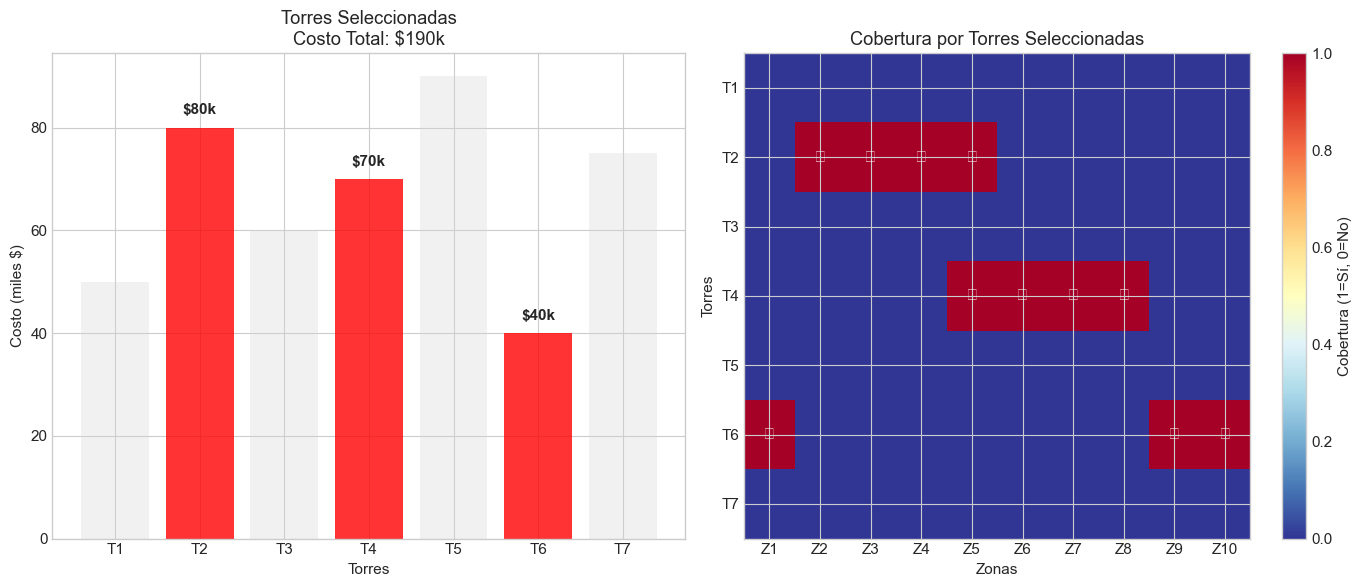

In [36]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Visualiza la seleccion de torres y la cobertura.

    Debe mostrar:
    - Que torres se seleccionaron (con costos)
    - Que zonas cubre cada torre seleccionada

    Args:
        y_opt: np.array (7,)
        costo_opt: float
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Torres seleccionadas con sus costos
    torres_seleccionadas = y_opt > 0.5
    colores = ['red' if sel else 'lightgray' for sel in torres_seleccionadas]
    
    bars1 = ax1.bar(nombres_torres_p3, costos_torres_p3, color=colores)
    
    # Aplicar alpha manualmente a cada barra
    for bar, sel in zip(bars1, torres_seleccionadas):
        if not sel:
            bar.set_alpha(0.3)
        else:
            bar.set_alpha(0.8)
    
    ax1.set_title(f'Torres Seleccionadas\nCosto Total: ${costo_opt:.0f}k')
    ax1.set_ylabel('Costo (miles $)')
    ax1.set_xlabel('Torres')
    
    # Añadir etiquetas en las torres seleccionadas
    for i, (bar, sel, costo) in enumerate(zip(bars1, torres_seleccionadas, costos_torres_p3)):
        if sel:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                    f'${costo}k', ha='center', va='bottom', fontweight='bold')
    
    # Panel 2: Matriz de cobertura
    # Crear matriz de cobertura solo para torres seleccionadas
    cobertura_visual = np.zeros((n_torres_p3, n_zonas_p3))
    for i in range(n_torres_p3):
        if torres_seleccionadas[i]:
            cobertura_visual[i] = cobertura_p3[i]
    
    im = ax2.imshow(cobertura_visual, cmap='RdYlBu_r', aspect='auto')
    
    # Configurar etiquetas
    ax2.set_xticks(range(n_zonas_p3))
    ax2.set_xticklabels([f'Z{i+1}' for i in range(n_zonas_p3)])
    ax2.set_yticks(range(n_torres_p3))
    ax2.set_yticklabels(nombres_torres_p3)
    
    ax2.set_title('Cobertura por Torres Seleccionadas')
    ax2.set_xlabel('Zonas')
    ax2.set_ylabel('Torres')
    
    # Añadir texto en las celdas
    for i in range(n_torres_p3):
        for j in range(n_zonas_p3):
            if torres_seleccionadas[i] and cobertura_p3[i, j]:
                ax2.text(j, i, '✓', ha='center', va='center', 
                        fontsize=12, fontweight='bold', color='white')
    
    # Colorbar
    plt.colorbar(im, ax=ax2, label='Cobertura (1=Sí, 0=No)')
    
    plt.tight_layout()
    plt.show()


y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print(f"Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")
print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ \begin{aligned}
a &= \text{amplitud del componente sinusoidal} \\
b &= \text{frecuencia del componente sinusoidal} \\
c &= \text{fase del componente sinusoidal} \\
d &= \text{amplitud del componente exponencial decreciente}
\end{aligned} $$

**Funcion objetivo:**

$$ \min_{a,b,c,d} \sum_{i=1}^{20} \left[ y_i^{obs} - \left( a \sin(b t_i + c) + d e^{-0.1 t_i} \right) \right]^2 $$

donde $y_i^{obs}$ son las mediciones observadas y $t_i$ son las posiciones conocidas del sensor.

**Restricciones:**

$$\begin{aligned}
& 0 \leq a \leq 5 \\
& 0 \leq b \leq 10 \\
& 0 \leq c \leq 2\pi \\
& -3 \leq d \leq 3
\end{aligned}$$

### 4.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:** `scipy.optimize.dual_annealing` o `scipy.optimize.differential_evolution`

**Justificacion (2-3 oraciones):** Este es un problema de optimización no lineal con múltiples mínimos locales debido a los términos trigonométricos en el modelo. Los optimizadores globales como `dual_annealing` o `differential_evolution` están diseñados específicamente para escapar de mínimos locales y encontrar el mínimo global, a diferencia de métodos locales como `minimize` que pueden quedar atrapados en soluciones subóptimas.

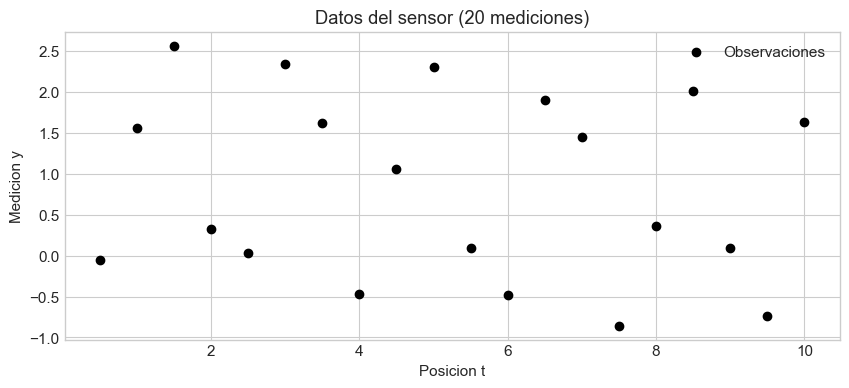

In [37]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [38]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """Calcula el error entre el modelo y las observaciones.

    Args:
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        float -- error total (escalar)
    """
    return np.sum((modelo_sensor(t_obs_p4, params) - y_obs_p4) ** 2)


def resolver_p4():
    """Resuelve el problema de calibracion.

    Returns:
        params_opt: np.array (4,) -- parametros optimos [a, b, c, d]
        error_opt: float -- error minimo encontrado
    """
    # Usar dual_annealing para optimización global
    result = dual_annealing(objetivo_p4, bounds=bounds_p4, seed=42)
    
    params_opt = result.x
    error_opt = result.fun
    
    return params_opt, error_opt

Solucion P4:
  a = 1.5090
  b = 9.0133
  c = 0.2358
  d = 1.4254
Error: 0.088386


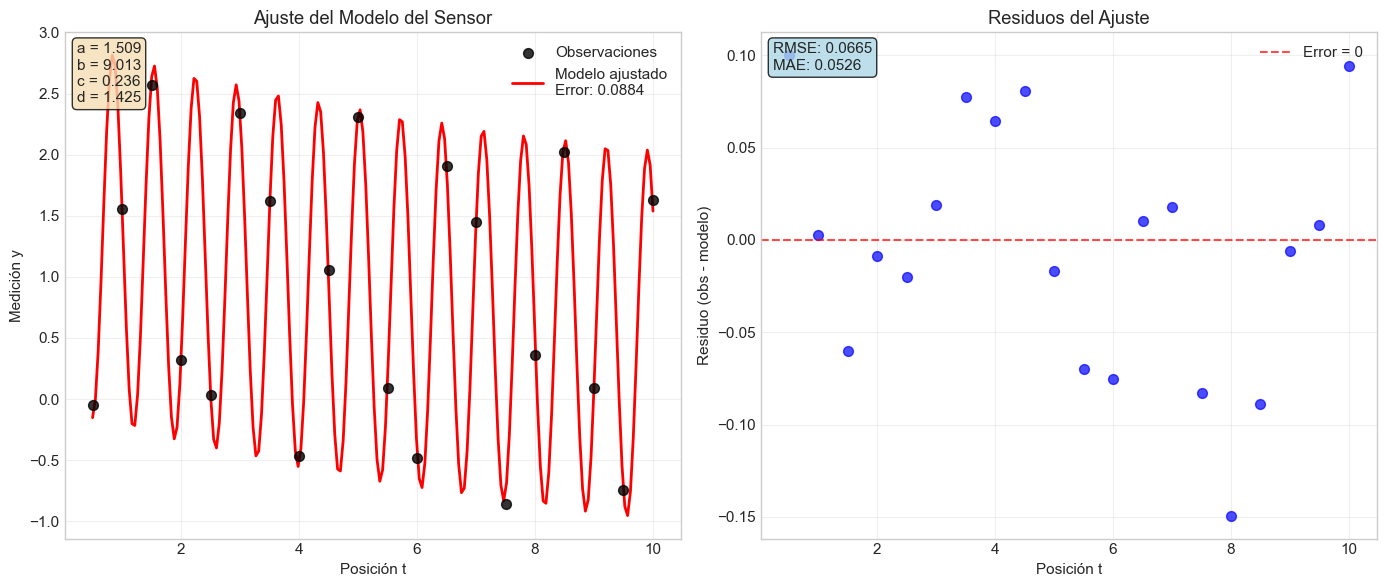

In [39]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """Visualiza el ajuste del modelo a los datos.

    Debe mostrar:
    - Datos observados (puntos)
    - Curva del modelo con parametros encontrados (linea)
    - Residuos (errores punto a punto)

    Args:
        params_opt: np.array (4,)
        error_opt: float
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Panel 1: Datos observados vs modelo ajustado
    # Crear puntos más densos para una curva suave
    t_denso = np.linspace(0.5, 10.0, 200)
    y_modelo_denso = modelo_sensor(t_denso, params_opt)
    y_modelo_obs = modelo_sensor(t_obs_p4, params_opt)
    
    # Graficar datos observados
    ax1.scatter(t_obs_p4, y_obs_p4, color='black', s=50, zorder=5, 
               label='Observaciones', alpha=0.8)
    
    # Graficar curva del modelo ajustado
    ax1.plot(t_denso, y_modelo_denso, 'r-', linewidth=2, 
            label=f'Modelo ajustado\nError: {error_opt:.4f}')
    
    ax1.set_xlabel('Posición t')
    ax1.set_ylabel('Medición y')
    ax1.set_title('Ajuste del Modelo del Sensor')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Mostrar parámetros en el gráfico
    param_text = f'a = {params_opt[0]:.3f}\nb = {params_opt[1]:.3f}\nc = {params_opt[2]:.3f}\nd = {params_opt[3]:.3f}'
    ax1.text(0.02, 0.98, param_text, transform=ax1.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Panel 2: Residuos (errores punto a punto)
    residuos = y_obs_p4 - y_modelo_obs
    
    ax2.scatter(t_obs_p4, residuos, color='blue', s=50, alpha=0.7)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='Error = 0')
    ax2.set_xlabel('Posición t')
    ax2.set_ylabel('Residuo (obs - modelo)')
    ax2.set_title('Residuos del Ajuste')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Estadísticas de los residuos
    rmse = np.sqrt(np.mean(residuos**2))
    mae = np.mean(np.abs(residuos))
    stats_text = f'RMSE: {rmse:.4f}\nMAE: {mae:.4f}'
    ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()


params_opt_p4, error_opt_p4 = resolver_p4()

print(f"Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error: {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica

<!-- ESCRIBE TU FORMULACION AQUI -->

**Variables de decision:**

$$ \begin{aligned}
y_i &= \begin{cases} 
1 & \text{si se abre el CD en la ciudad } i \\
0 & \text{si no se abre el CD en la ciudad } i 
\end{cases} \quad i = 1,2,3,4 \\
\\
x_{ij} &= \text{unidades enviadas del CD } i \text{ al cliente } j, \quad i = 1,2,3,4; \quad j = 1,2,3,4,5,6
\end{aligned} $$

donde:
- $y_1$ = Abrir CD en Guadalajara, $y_2$ = Monterrey, $y_3$ = CDMX, $y_4$ = Mérida
- $x_{ij}$ = Flujo de productos del centro $i$ al cliente $j$

**Funcion objetivo:**

$$ \min Z = \sum_{i=1}^{4} f_i y_i + \sum_{i=1}^{4} \sum_{j=1}^{6} c_{ij} x_{ij} $$

donde $f_i$ son los costos fijos de apertura y $c_{ij}$ son los costos de envío por unidad.

**Restricciones:**

$$\begin{aligned}
& \text{Satisfacción de demanda (cada cliente debe recibir su demanda completa):} \\
& \sum_{i=1}^{4} x_{ij} = d_j \quad \forall j = 1,2,3,4,5,6 \\
& \\
& \text{Capacidad de los CDs (no exceder la capacidad si está abierto):} \\
& \sum_{j=1}^{6} x_{ij} \leq C_i y_i \quad \forall i = 1,2,3,4 \\
& \\
& \text{Envío solo desde CDs abiertos:} \\
& x_{ij} \leq M y_i \quad \forall i = 1,2,3,4; \quad \forall j = 1,2,3,4,5,6 \\
& \\
& \text{No negatividad y variables binarias:} \\
& x_{ij} \geq 0 \quad \forall i,j \\
& y_i \in \{0,1\} \quad \forall i = 1,2,3,4
\end{aligned}$$

donde $d_j$ son las demandas, $C_i$ son las capacidades, y $M$ es un número grande (big-M).

### 5.2 Eleccion de optimizador

<!-- ESCRIBE TU RESPUESTA AQUI -->

**Optimizador elegido:**
`milp`
**Justificacion (2-3 oraciones):**
Parecido a la pregunta sobre las torres tenemos un problema con variables discretas. Donde abrir es una variable discreta y la cantidad es continua. 

In [40]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [ ]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    """Calcula el costo total: costos fijos + costos de envio.

    Args:
        y: np.array (4,) -- 1 si el CD esta abierto, 0 si no
        X: np.array (4, 6) -- unidades enviadas de CD i a cliente j

    Returns:
        float -- costo total
    """
    # la variable y indica si el CD esta abierto o no, por lo que multiplicamos el costo fijo por y para cada CD
    costo_fijo= np.dot(costos_fijos_p5, y)
    costo_envio= np.sum(costos_envio_p5 * X) # multiplicamos elemento a elemento el costo de envio por las unidades enviadas y luego sumamos todo para obtener el costo total de envio
    return costo_fijo + costo_envio


def verificar_p5(y, X):
    """Verifica si la solucion cumple todas las restricciones.

    Args:
        y: np.array (4,) -- apertura de CDs
        X: np.array (4, 6) -- envios

    Returns:
        dict con:
            'factible': bool
            'demanda_cumplida': np.array (6,) -- unidades recibidas por cada cliente
            'capacidad_usada': np.array (4,) -- capacidad usada por cada CD
    """
    # Calcular cuánto recibe cada cliente (suma por columnas)
    demanda_cumplida = np.sum(X, axis=0)  # Suma de envíos de todos los CDs a cada cliente
    
    # Calcular cuánto envía cada CD (suma por filas)
    capacidad_usada = np.sum(X, axis=1)  # Suma de envíos de cada CD a todos los clientes
    
    # Verificar todas las restricciones:
    # 1. Demandas satisfechas exactamente
    demandas_ok = np.allclose(demanda_cumplida, demandas_p5)
    
    # 2. Capacidad no excedida (solo CDs abiertos pueden enviar)
    capacidad_ok = np.all(capacidad_usada <= capacidades_p5 * y)
    
    # 3. Solo enviar desde CDs abiertos (no envío desde CDs cerrados)
    envio_solo_abiertos = True
    for i in range(n_cds_p5):
        if y[i] == 0 and np.any(X[i] > 1e-6):  # Si CD cerrado pero envía algo
            envio_solo_abiertos = False
            break
    
    # 4. No negatividad
    no_negatividad = np.all(X >= 0) and np.all(y >= 0)
    
    factible = demandas_ok and capacidad_ok and envio_solo_abiertos and no_negatividad
    
    return {
        'factible': factible,
        'demanda_cumplida': demanda_cumplida,
        'capacidad_usada': capacidad_usada
    } 


def resolver_p5():
    """Resuelve el problema de red de distribucion.

    Returns:
        y_opt: np.array (4,) -- 1 si el CD se abre, 0 si no
        X_opt: np.array (4, 6) -- envios optimos
        costo_opt: float -- costo total minimo
    """
    # Configurar el problema MILP
    # Vector de variables: [y1, y2, y3, y4, x11, x12, ..., x16, x21, ..., x46]
    # Total de variables: 4 (y) + 24 (X) = 28 variables
    
    n_vars = n_cds_p5 + n_cds_p5 * n_clientes_p5  # 4 + 24 = 28
    
    # Vector de costos para la función objetivo
    c = np.zeros(n_vars)
    # Primeras 4 variables son los costos fijos (y)
    c[:n_cds_p5] = costos_fijos_p5
    # Siguientes 24 variables son los costos de envío (X)
    c[n_cds_p5:] = costos_envio_p5.flatten()
    
    # Configurar integrality: las primeras 4 variables (y) son binarias
    integrality = np.zeros(n_vars)
    integrality[:n_cds_p5] = 1  # Variables y son binarias
    # Las variables X son continuas (integrality = 0)
    
    # Configurar bounds
    bounds = np.zeros((n_vars, 2))
    # Variables y: entre 0 y 1 (binarias)
    bounds[:n_cds_p5] = [0, 1]
    # Variables X: no negativas, sin límite superior específico
    bounds[n_cds_p5:] = [0, np.inf]
    
    # ===== RESTRICCIONES =====
    constraints = []
    
    # 1. Restricciones de demanda: cada cliente debe recibir exactamente su demanda
    # Para cada cliente j: x1j + x2j + x3j + x4j = demanda_j
    for j in range(n_clientes_p5):
        A_demanda = np.zeros(n_vars)
        # Solo las variables X que corresponden al cliente j
        for i in range(n_cds_p5):
            idx_x = n_cds_p5 + i * n_clientes_p5 + j
            A_demanda[idx_x] = 1
        
        constraints.append(LinearConstraint(A_demanda, demandas_p5[j], demandas_p5[j]))
    
    # 2. Restricciones de capacidad: suma de envíos de cada CD ≤ capacidad * y_i
    # Para cada CD i: xi1 + xi2 + ... + xi6 ≤ capacidad_i * yi
    for i in range(n_cds_p5):
        A_capacidad = np.zeros(n_vars)
        # Variable binaria yi (con coeficiente negativo para la capacidad)
        A_capacidad[i] = -capacidades_p5[i]
        # Variables de envío del CD i
        for j in range(n_clientes_p5):
            idx_x = n_cds_p5 + i * n_clientes_p5 + j
            A_capacidad[idx_x] = 1
        
        constraints.append(LinearConstraint(A_capacidad, -np.inf, 0))
    
    M = np.sum(demandas_p5)  # Un número grande suficiente
    for i in range(n_cds_p5):
        for j in range(n_clientes_p5):
            A_envio = np.zeros(n_vars)
            # Variable binaria yi (con coeficiente negativo)
            A_envio[i] = -M
            # Variable de envío xij
            idx_x = n_cds_p5 + i * n_clientes_p5 + j
            A_envio[idx_x] = 1
            
            constraints.append(LinearConstraint(A_envio, -np.inf, 0))
    
    bounds_obj = Bounds(bounds[:, 0], bounds[:, 1])
    result = milp(c=c, constraints=constraints, bounds=bounds_obj, integrality=integrality)
    
    # Extraer las soluciones
    sol = result.x
    y_opt = sol[:n_cds_p5]
    X_opt = sol[n_cds_p5:].reshape((n_cds_p5, n_clientes_p5))
    costo_opt = result.fun
    
    return y_opt, X_opt, costo_opt

Solucion P5:
  CDMX: ABIERTO (480/600 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C6: 80 unidades
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 150 unidades
    -> Cliente C5: 100 unidades
    -> Cliente C6: 100 unidades
Costo total: $5130k
Factible: True


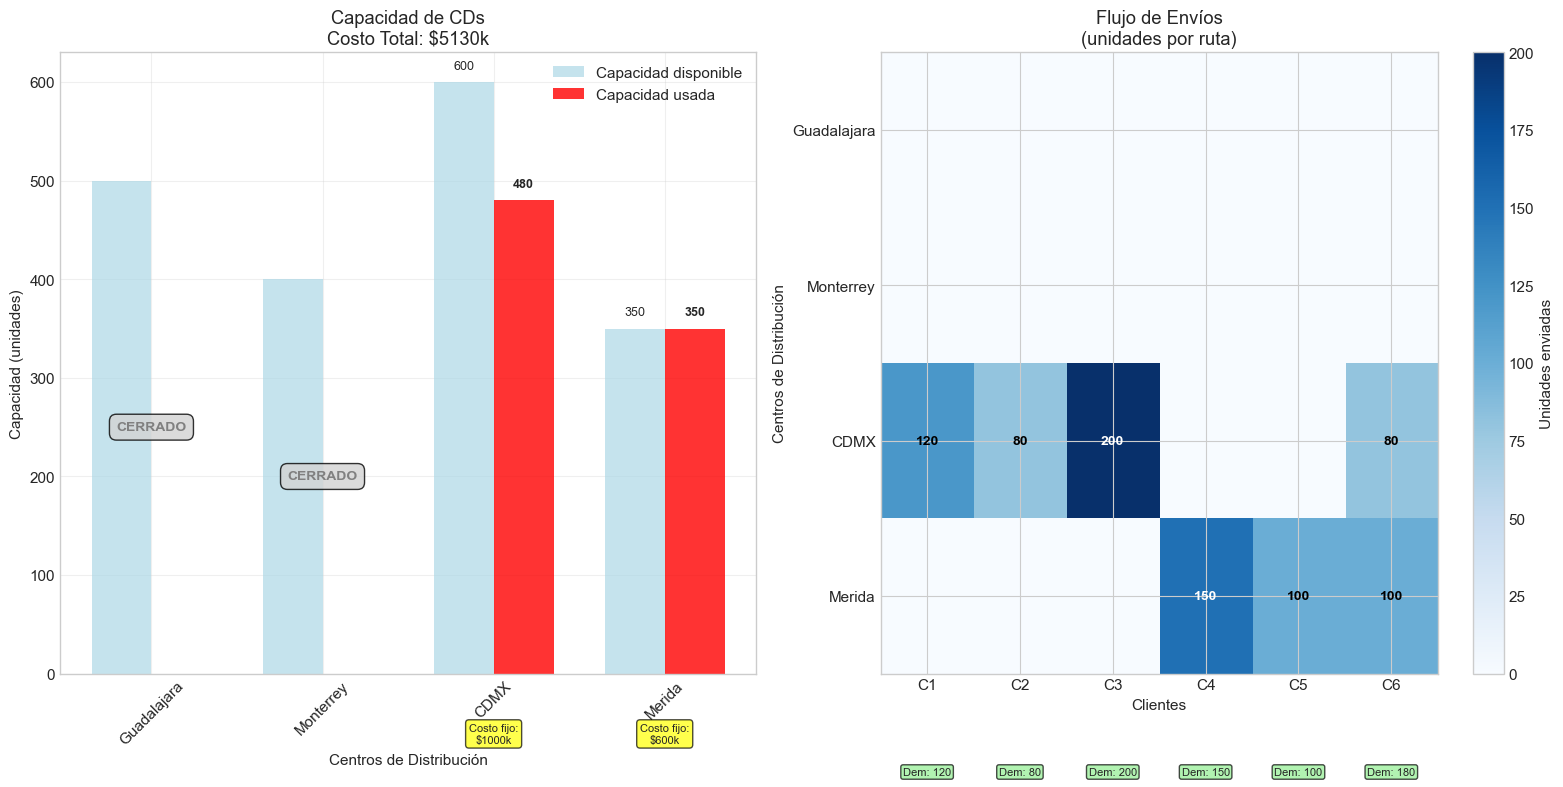

In [45]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    """Visualiza la red de distribucion.

    Debe mostrar:
    - Que CDs estan abiertos (con capacidad usada vs disponible)
    - Flujo de envios: de cada CD a cada cliente

    Args:
        y_opt: np.array (4,)
        X_opt: np.array (4, 6)
        costo_opt: float
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Panel 1: CDs abiertos con capacidad usada vs disponible
    capacidad_usada = np.sum(X_opt, axis=1)
    cds_abiertos = y_opt > 0.5
    
    # Crear gráfico de barras para capacidades
    x_pos = np.arange(n_cds_p5)
    width = 0.35
    
    # Barras de capacidad disponible
    bars1 = ax1.bar(x_pos - width/2, capacidades_p5, width, 
                   label='Capacidad disponible', color='lightblue', alpha=0.7)
    
    # Barras de capacidad usada (solo para CDs abiertos)
    capacidad_usada_display = np.where(cds_abiertos, capacidad_usada, 0)
    bars2 = ax1.bar(x_pos + width/2, capacidad_usada_display, width,
                   label='Capacidad usada', color='red', alpha=0.8)
    
    # Configurar el gráfico
    ax1.set_xlabel('Centros de Distribución')
    ax1.set_ylabel('Capacidad (unidades)')
    ax1.set_title(f'Capacidad de CDs\nCosto Total: ${costo_opt:.0f}k')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(ciudades_p5, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Añadir etiquetas con valores y costos fijos
    for i, (cap_disp, cap_usada, abierto, costo_fijo) in enumerate(zip(capacidades_p5, capacidad_usada, cds_abiertos, costos_fijos_p5)):
        if abierto:
            # Etiqueta en capacidad disponible
            ax1.text(i - width/2, cap_disp + 10, f'{cap_disp}', 
                    ha='center', va='bottom', fontsize=9)
            # Etiqueta en capacidad usada
            ax1.text(i + width/2, cap_usada + 10, f'{cap_usada:.0f}', 
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
            # Etiqueta de costo fijo
            ax1.text(i, -50, f'Costo fijo:\n${costo_fijo}k', 
                    ha='center', va='top', fontsize=8, 
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        else:
            # Marcar CDs cerrados
            ax1.text(i, cap_disp/2, 'CERRADO', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='gray',
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))
    
    # Panel 2: Matriz de flujos (heatmap)
    # Solo mostrar flujos de CDs abiertos
    X_display = np.where(cds_abiertos.reshape(-1, 1), X_opt, 0)
    
    im = ax2.imshow(X_display, cmap='Blues', aspect='auto', interpolation='nearest')
    
    # Configurar etiquetas
    ax2.set_xticks(range(n_clientes_p5))
    ax2.set_xticklabels([f'C{i+1}' for i in range(n_clientes_p5)])
    ax2.set_yticks(range(n_cds_p5))
    ax2.set_yticklabels(ciudades_p5)
    
    ax2.set_title('Flujo de Envíos\n(unidades por ruta)')
    ax2.set_xlabel('Clientes')
    ax2.set_ylabel('Centros de Distribución')
    
    # Añadir texto en las celdas con los valores de flujo
    for i in range(n_cds_p5):
        for j in range(n_clientes_p5):
            if cds_abiertos[i] and X_opt[i, j] > 0.5:
                # Texto blanco para valores altos, negro para valores bajos
                color = 'white' if X_opt[i, j] > np.max(X_opt) * 0.6 else 'black'
                ax2.text(j, i, f'{X_opt[i, j]:.0f}', 
                        ha='center', va='center', fontsize=10, 
                        fontweight='bold', color=color)
    
    # Añadir demandas en la parte inferior
    for j in range(n_clientes_p5):
        ax2.text(j, n_cds_p5 + 0.1, f'Dem: {demandas_p5[j]}', 
                ha='center', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.7))
    
    # Colorbar
    plt.colorbar(im, ax=ax2, label='Unidades enviadas')
    
    plt.tight_layout()
    plt.show()


y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print(f"Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)